In [1]:
import sys
sys.path.append('../')

In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
import matplotlib.pyplot as plt
import librosa

from src.config.paths import LIBRI_PATH
from src.core.speech.preproc import log_mel_spectrogram, spec_augment

## SpecAugment

In [4]:
signal, sr = librosa.load(LIBRI_PATH / 'test-clean' / '260' / '123286' / '260-123286-0010.flac', sr=16000)

log_mel = log_mel_spectrogram(signal, sr)

In [5]:
print(len(signal) / sr, log_mel.shape)

2.575 (64, 258)


**Why is T = 258?**
- 2.575 second clip resampled to 16,000 Hz
- 41,200 samples
- 41,200 / HOP_LEN i.e., / 160 = 257.5
- 258 log_mel column vectors

**Interpreting time warping**
- one column vector represents one frame of information each <br>
- one frame is 160 samples or 10ms
- time warping 50 units of time for the spectrograph corresponds to time warping 0.5s of audio

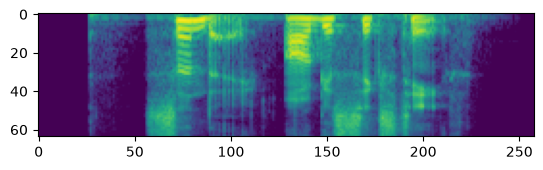

In [6]:
plt.imshow(log_mel)

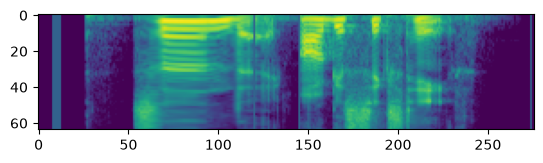

In [17]:
plt.imshow(spec_augment(log_mel))